### 找出所有的突变体样本，画图

In [1]:
# 从整个数据集
import torch
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from collections import defaultdict

In [2]:
# kcat
kcatTrainPair = torch.load("../Data/KCATTrainPairInfo")
kcatTestPair = torch.load("../Data/KCATTestPairInfo")
# km
kmTrainPair = torch.load("../Data/KMTrainPairInfo")
kmTestPair = torch.load("../Data/KMTestPairInfo")
# kkm
kkmTrainPair = torch.load("../Data/KKMTrainPairInfo")
kkmTestPair = torch.load("../Data/KKMTestPairInfo")
# 加载映射
allKineticsData = torch.load("../../KCAT/Data/all_kinetics_data.pt")

In [3]:
# 建立索引
def compare2seq(wild, mutant):
    if len(wild) != len(mutant):
        return False, None
    sumHits = 0
    mutanInfo = {}
    for ind, (k1, k2) in enumerate(zip(wild, mutant)):
        if k1 != k2:
            mutanInfo[ind] = (k1, k2)
        else:
            sumHits += 1
    if sumHits/len(wild) < 0.90 or len(mutanInfo) == 0:
        return False, mutanInfo
    else:
        return True, mutanInfo
def createMutantIndex(kineticsData):
    wildIndex = defaultdict(dict)
    for ind, item in enumerate(kineticsData):
        if item['type'] == 'wild':
            organism = item['organism']
            smiles = item['smiles']
            sequence = item['sequence']
            if wildIndex[organism].get(smiles) is None:
                wildIndex[organism][smiles] = {}
                wildIndex[organism][smiles][sequence] = (ind, float(item['value']))
            else:
                if wildIndex[organism][smiles].get(sequence) is not None:
                    raise ValueError
                wildIndex[organism][smiles][sequence] = (ind, float(item['value']))

    wildIndex = dict(wildIndex)
    newKineticsData = []
    for item in kineticsData:
        if item['type'] == 'wild':
            item['mi'] = None
        else:
            if wildIndex.get(item['organism']) is None or wildIndex[item['organism']].get(item['smiles']) is None:
                item['mi'] = None
            else:
                for k in wildIndex[item['organism']][item['smiles']]:
                    isMutant, mutantInfo = compare2seq(k, item['sequence'])
                    if isMutant:
                        item['mi'] = {
                                        'wild value':wildIndex[item['organism']][item['smiles']][k][1],
                                        'wild index':wildIndex[item['organism']][item['smiles']][k][0],
                                        'sites':mutantInfo
                                     }
                        break
        if item.get('mi') is None:
            item['mi'] = None
        newKineticsData.append(item)
    return newKineticsData

In [4]:
kcat_data = createMutantIndex(allKineticsData['kinetics_data']['kcat'])
km_data = createMutantIndex(allKineticsData['kinetics_data']['km'])
kkm_data = createMutantIndex(allKineticsData['kinetics_data']['kkm'])

In [5]:
kcat_df = pd.DataFrame(kcat_data)
km_df = pd.DataFrame(km_data)
kkm_df = pd.DataFrame(kkm_data)
kcat_df['kinetics_type'] = 'kcat'
km_df['kinetics_type'] = 'km'
kkm_df['kinetics_type'] = 'kkm'
data = pd.concat([kcat_df, km_df, kkm_df], axis=0)
data['value'] = data['value'].astype(float)
data = data[data['value'] > 0]
data['value'] = np.log10(data['value'])

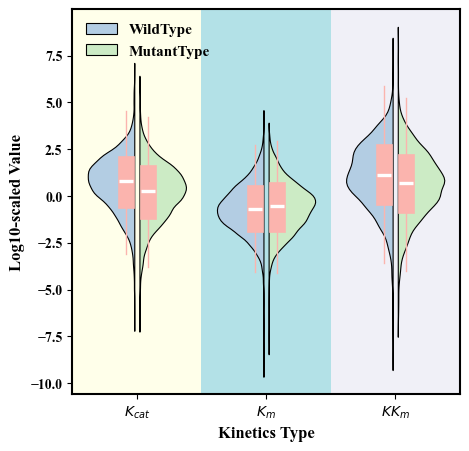

In [41]:
plt.figure(figsize=(5,5))
# plt.rc('font',**{'family':'Times New Roman','weight':'bold'})
ax = sns.violinplot(data, x='kinetics_type', 
               y='value', 
               hue='type', 
               split=True, 
#                log_scale=10, 
               inner="box", 
               dodge=True, 
               gap=0.1, 
               inner_kws=dict(box_width=12, whis_width=1, color='#fbb4ae'),
               density_norm='width',
               common_norm=True,
               palette={'wild':'#b3cde3', 'mutant':'#ccebc5'},
#                legend='full'
               linewidth=0.8,
               linecolor='#000',
               saturation=1
              )
rect1 = patches.Rectangle((-0.5, -11.0), 1, 21, facecolor='#ffffcc', zorder=0, alpha=0.4)
rect2 = patches.Rectangle((0.5, -11.0), 1, 21, facecolor='#41b6c4', zorder=0, alpha=0.4)
rect3 = patches.Rectangle((1.5, -11.0), 1, 21, facecolor='#dadaeb', zorder=0, alpha=0.4)
ax.add_patch(rect1)
ax.add_patch(rect2)
ax.add_patch(rect3)
# plt.legend(frameon=True, prop={"size":11, 'weight':'bold', 'family':'Times New Roman'})
ax.set_ylabel("Log10-scaled Value", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
ax.set_xlabel("Kinetics Type", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
plt.yticks(**{'family':'Times New Roman', 'weight':'bold', 'size':10})
plt.xticks(ticks=[0,1,2],labels=['$K_{cat}$', '$K_{m}$', '$KK_{m}$'],**{'family':'Times New Roman', 'weight':'bold', 'size':10})
plt.legend(handles=[ax.collections[0], ax.collections[1]], frameon=False,loc=2,labels=['WildType', 'MutantType'], prop={"size":11, 'family':'Times New Roman', 'weight':'bold'})
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
# plt.savefig(f"../Fig/Fig14-MACCSKeys-Wild_Mutant_Distribution.png", dpi=600, bbox_inches='tight')

{'whiskers': [<matplotlib.lines.Line2D at 0x7f1871234fa0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f18712354b0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f1871234c40>],
 'medians': [<matplotlib.lines.Line2D at 0x7f18712359f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f1871235f30>],
 'means': [<matplotlib.lines.Line2D at 0x7f1871235d50>]}

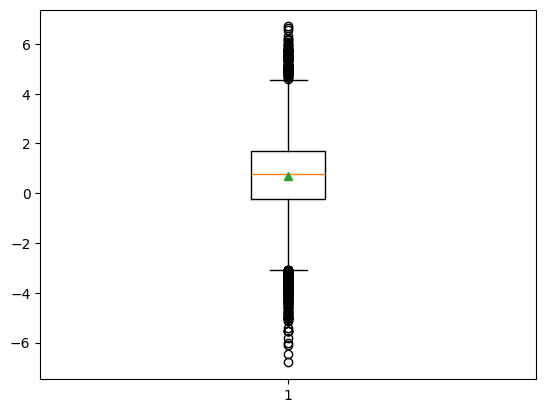

In [51]:
plt.boxplot([data[(data['kinetics_type']=='kcat')&(data['type'] == 'wild')]['value']], showmeans=True)

### 突变体测试集训练集分布

In [34]:
import torch
import os
import sys
sys.path.append("../")
from tools import getPairInfo, metric
from predictor_iter import predict
kineticsType = 'kkm'
testPair = torch.load(f"../Data/{kineticsType.upper()}TestPairInfo")
Type = []

if kineticsType == 'kcat':
    proxy_data1  = kcat_data
    proxy_data2 = km_data
elif kineticsType == 'km':
    proxy_data1  = km_data
    proxy_data2 = kcat_data
else:
    proxy_data1  = kkm_data
    proxy_data2 = kcat_data

for item in testPair:
    if len(item[3]) == 1:
        if proxy_data1[item[3][0]]['type'] == 'wild':
            Type.append(0)
        else:
            Type.append(1)
    else:
        if proxy_data2[item[3][0]]['type'] == 'wild':
            Type.append(0)
        else:
            Type.append(1)
modelPath = {
    'kcat':"../../IterTransferLearning/KCATModel/confirm-MACCS#openKKmInfer#openLog10-KCAT-train-8/model/pre-train-trainR2:0.9408-devR2=0.7459-RMSE=0.7751-MAE=0.4787-epoch=3",
    'km':"../../IterTransferLearning/KMModel/confirm-MACCS#openKKmInfer#openLog10-KM-train-8/model/pre-train-trainR2:0.9303-devR2=0.7163-RMSE=0.6960-MAE=0.4802-epoch=3",
    'kkm':"../../IterTransferLearning/KKMModel/confirm-MACCS#openKKmInfer#openLog10-KKM-train-8/model/pre-train-trainR2:0.9188-devR2=0.8245-RMSE=0.7592-MAE=0.5030-epoch=4"
}
Real, Pre = predict(
                    kineticsType.upper(),
                    modelPath[f'{kineticsType}'],
                    testPair,
                    f"../../{kineticsType.upper()}/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../{kineticsType.upper()}/Data/NewestFeature/index_smiles",
                    True,
                    torch.device("cuda:1"),
                    "MACCSKeys"
                   )
draw_df = pd.DataFrame({'kinetics_type':Type, 'prediction':Pre, 'experiment':Real})

log10:True molType:MACCSKeys
complex
complex


100%|█████████████████████████████████████████████████████████████| 20/20 [00:06<00:00,  3.07it/s]


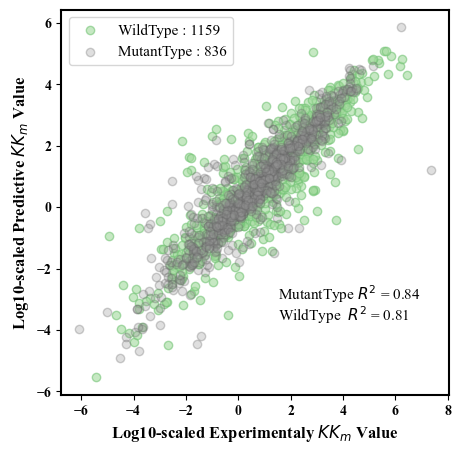

In [35]:
plt.figure(figsize=(5,5))
wildData = draw_df[draw_df['kinetics_type']==0]
mutantData = draw_df[draw_df['kinetics_type']==1]
plt.scatter(wildData['experiment'],
            wildData['prediction'], 
            c='#a1d99b',
            alpha=0.6,
            edgecolors='#74c476',
            label="WildType"
           )
plt.scatter(mutantData['experiment'],
            mutantData['prediction'], 
            c='#969696',
            alpha=0.3,
            edgecolors='#636363',
            label="MutantType"
           )
ax = plt.gca()

ax.set_ylabel("Log10-scaled Predictive $KK_{m}$ Value", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
ax.set_xlabel("Log10-scaled Experimentaly $KK_{m}$ Value", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
plt.yticks(**{'family':'Times New Roman', 'weight':'bold', 'size':10})
plt.xticks(**{'family':'Times New Roman', 'weight':'bold', 'size':10})
if kineticsType == 'kcat':
    plt.text(1.5, -3, f"MutantType $R^2$ = {metric(mutantData['prediction'],mutantData['experiment'], True)['r2']:.2}", fontweight="normal", fontsize=11, family='Times New Roman')
    plt.text(1.5, -3.7, f"WildType  $R^2$ = {metric(wildData['prediction'],wildData['experiment'], True)['r2']:.2}", fontweight="normal", fontsize=11, family='Times New Roman')
elif kineticsType == 'km':
    plt.text(-0.7, -4.5, f"MutantType $R^2$ = {metric(mutantData['prediction'],mutantData['experiment'], True)['r2']:.2}", fontweight="normal", fontsize=11, family='Times New Roman')
    plt.text(-0.7, -5, f"WildType  $R^2$ = {metric(wildData['prediction'],wildData['experiment'], True)['r2']:.2}", fontweight="normal", fontsize=11, family='Times New Roman')
else:
    plt.text(1.5, -3, f"MutantType $R^2$ = {metric(mutantData['prediction'],mutantData['experiment'], True)['r2']:.2}", fontweight="normal", fontsize=11, family='Times New Roman')
    plt.text(1.5, -3.7, f"WildType  $R^2$ = {metric(wildData['prediction'],wildData['experiment'], True)['r2']:.2}", fontweight="normal", fontsize=11, family='Times New Roman')

plt.legend(handles=[ax.collections[0], ax.collections[1]], frameon=True,loc=2,labels=[f'WildType : {len(wildData)}', f'MutantType : {len(mutantData)}'], prop={"size":11, 'family':'Times New Roman', 'weight':'normal'})
ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
plt.savefig(f"../Fig/Fig14-MACCSKeys-{kineticsType.upper()}-Wild_Mutant_Distribution.png", dpi=600, bbox_inches='tight')

In [29]:
metric(wildData['prediction'],wildData['experiment'], True)

{'MAE': 0.5274147577134265,
 'rmse': 0.7555410045709392,
 'r2': 0.6595470626745913,
 'r': 0.8152305390588485,
 'p_value': 0.0,
 'samples': 1818}

### 统计突变位点数

In [38]:
import math
sites = []
basicValue = []
baseIndex = []
ecNums = []
mutant = []
for item in testPair:
    if len(item[3]) == 1:
        if proxy_data1[item[3][0]]['type'] == 'wild' or proxy_data1[item[3][0]]['mi'] is None:
            sites.append(0)
            basicValue.append(None)
            baseIndex.append(None)
            ecNums.append(proxy_data1[item[3][0]]['ec'])
            mutant.append(None)
        else:
            sites.append(len(proxy_data1[item[3][0]]['mi']['sites']))
            basicValue.append(math.log10(proxy_data1[item[3][0]]['mi']['wild value']))
            baseIndex.append(proxy_data1[item[3][0]]['mi']['wild index'])
            ecNums.append(proxy_data1[item[3][0]]['ec'])
            mutant.append(proxy_data1[item[3][0]]['mi']['sites'])
#     else:
#         if proxy_data2[item[3][0]]['type'] == 'wild' or proxy_data2[item[3][0]]['mi'] is None:
#             sites.append(0)
#             Type.append(0)
#             basicValue.append(None)
#             baseIndex.append(None)
#             ecNums.append(proxy_data2[item[3][0]]['ec'])
#             mutant.append(None)
#         else:
#             Type.append(len(proxy_data2[item[3][0]]['mi']['sites']))
#             basicValue.append(math.log10(proxy_data2[item[3][0]]['mi']['wild value']))
#             baseIndex.append(proxy_data2[item[3][0]]['mi']['wild index'])
#             ecNums.append(proxy_data2[item[3][0]]['ec'])
#             mutant.append(proxy_data2[item[3][0]]['mi']['sites'])

In [39]:
draw_df['sites'] = sites
draw_df['wild value'] = basicValue
draw_df['change rate'] = draw_df['experiment'] - draw_df['wild value']
draw_df['ec'] = ecNums
draw_df['wild index'] = baseIndex
draw_df['mutant sites'] = mutant

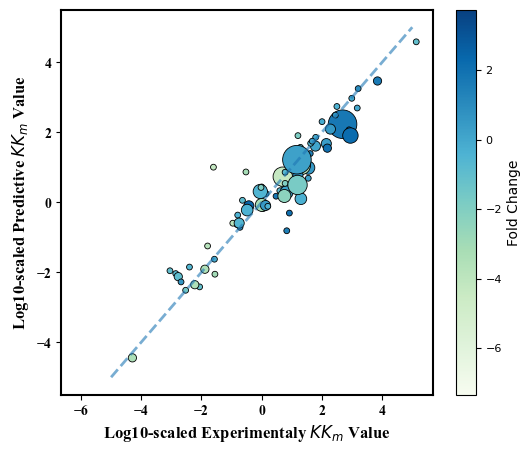

In [40]:
plt.figure(figsize=(6,5))
mutantData = draw_df[(draw_df['kinetics_type']==1)&(draw_df['sites'] != 0)]
# ax = sns.scatterplot(mutantData,
#                x=mutantData['experiment'],
#                y=mutantData['prediction'],
#                hue='sites',
#                size='change rate',
#                sizes=(0.1, 100),
#                legend=False,
#                edgecolors='#000',
#                linewidth=0.6,
#                alpha=0.8,
# #                hue_norm=(0, 0.1),
#                palette='pastel6'
#                )
sc = plt.scatter(
           x=mutantData['experiment'],
           y=mutantData['prediction'],
           c=mutantData['change rate'],
           s=((mutantData['sites']-1)/17)*300,
           norm='linear',
           linewidth=0.6,
           edgecolors='#000',
           cmap='GnBu'
           )
line = np.linspace(-5, 5)
plt.plot(line, line, linewidth=2, alpha=0.6, linestyle='dashed')
cbar = plt.colorbar(sc)
cbar.ax.tick_params(labelsize=8)
cbar.set_label('Fold Change', size=10)

ax = plt.gca()
ax.set_ylabel("Log10-scaled Predictive $KK_{m}$ Value", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
ax.set_xlabel("Log10-scaled Experimentaly $KK_{m}$ Value", fontdict={'family':'Times New Roman', 'weight':'bold', 'size':12})
plt.yticks(**{'family':'Times New Roman', 'weight':'bold', 'size':10})
plt.xticks(**{'family':'Times New Roman', 'weight':'bold', 'size':10})

ax.spines['bottom'].set_linewidth(1.5)
ax.spines['left'].set_linewidth(1.5)
ax.spines['top'].set_linewidth(1.5)
ax.spines['right'].set_linewidth(1.5)
plt.savefig(f"../Fig/Fig14-MACCSKeys-{kineticsType.upper()}-Mutant_Distribution.png", dpi=600, bbox_inches='tight')

### 绘制不同突变数的性能

In [26]:
mutantData = draw_df[(draw_df['kinetics_type']==1)&(draw_df['sites'] != 0)]
for i in mutantData['sites'].unique():
    subdata = mutantData[mutantData['sites']==i]
    if len(subdata['prediction']) > 2:
        v = metric(subdata['prediction'], subdata['experiment'], True)
        print(f"{i},{v['MAE']:.3f},{v['rmse']:.3f},{v['r2']:.3f},{v['r']:.3f},{v['samples']}")

1,0.496,0.736,0.827,0.911,314
4,0.266,0.290,0.933,0.984,8
3,0.293,0.376,0.979,0.993,8
6,0.441,0.487,0.205,0.954,4
2,0.436,0.653,0.868,0.934,48
12,0.324,0.427,-1.665,0.263,3
5,0.499,0.710,0.192,0.606,3


<BarContainer object of 7 artists>

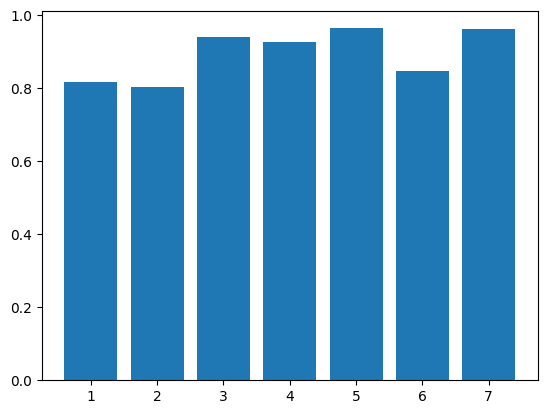

In [182]:
x = [1,2,3,4,5,6,7]
y = [0.818, 0.804, 0.940, 0.927, 0.964, 0.846, 0.961]
plt.bar(x, y)

In [184]:
len(mutantData['wild index'].unique())

783

In [186]:
uniqueIndex = []
for item in mutantData['wild index'].unique():
    subdata = mutantData[mutantData['wild index'] == item]
    if len(subdata) > 3:
        res = metric(subdata['prediction'], subdata['experiment'], True)
        uniqueIndex.append((item, len(subdata), res['r2']))

In [193]:
uniqueIndex

[(22135.0, 4, -0.20542199232612735),
 (7691.0, 4, -0.11733474362006713),
 (30237.0, 7, 0.7338155670685111),
 (15826.0, 4, 0.9546493050851288),
 (1862.0, 4, -3.132547368096743),
 (26708.0, 4, 0.9755618421642288),
 (27936.0, 5, 0.015435804888302873),
 (24028.0, 4, 0.49842445137845937),
 (32447.0, 6, 0.28388871912916613),
 (20398.0, 4, 0.5871078323168775),
 (22236.0, 5, -2.385635658371303),
 (24948.0, 4, 0.6952446077251924),
 (5614.0, 4, 0.737647355795908),
 (20809.0, 4, 0.3536468611023378),
 (25466.0, 4, -2.1598761512260696),
 (26939.0, 4, 0.9329659357954531),
 (26332.0, 6, -1.334515185300595),
 (30236.0, 7, 0.5033244556492245),
 (20975.0, 4, -4.091048211212339),
 (22453.0, 7, 0.7961161711551604),
 (22981.0, 4, -1.1132928415995633),
 (28349.0, 4, 0.9136610850787947),
 (25197.0, 4, 0.9422900171819897),
 (34639.0, 4, -0.11981155764739193)]

In [200]:
mutantData[mutantData['wild index'] == 22453.0]

,kinetics_type,prediction,experiment,sites,wild value,change rate,ec,wild index,mutant sites
915,1,0.878812,0.690196,2,1.462398,-0.772202,1.5.1.3,22453.0,"{84: ('C', 'A'), 151: ('C', 'S')}"
1100,1,0.734737,0.662758,3,1.462398,-0.799640,1.5.1.3,22453.0,"{0: ('M', 'A'), 84: ('C', 'A'), 151: ('C', 'S')}"
1519,1,1.227771,1.385606,1,1.462398,-0.076792,1.5.1.3,22453.0,"{41: ('M', 'Q')}"
1796,1,0.389972,0.755875,1,1.462398,-0.706523,1.5.1.3,22453.0,"{43: ('R', 'K')}"
2118,1,1.043315,1.093422,1,1.462398,-0.368976,1.5.1.3,22453.0,"{41: ('M', 'I')}"
2361,1,0.361606,0.385606,1,1.462398,-1.076792,1.5.1.3,22453.0,"{43: ('R', 'C')}"
3165,1,1.466912,1.482874,1,1.462398,0.020476,1.5.1.3,22453.0,"{41: ('M', 'C')}"


In [194]:
mutantData[mutantData['wild index'] == 30236.0]

,kinetics_type,prediction,experiment,sites,wild value,change rate,ec,wild index,mutant sites
834,1,0.434673,0.361728,1,0.90309,-0.541362,2.1.1.45,30236.0,"{178: ('R', 'S')}"
1976,1,-0.443113,-0.568636,1,0.90309,-1.471726,2.1.1.45,30236.0,"{22: ('R', 'V')}"
2021,1,-0.948535,-0.958607,1,0.90309,-1.861697,2.1.1.45,30236.0,"{22: ('R', 'L')}"
2636,1,-0.251594,-1.301030,1,0.90309,-2.204120,2.1.1.45,30236.0,"{315: ('V', 'W')}"
2738,1,-0.219780,0.285557,2,0.90309,-0.617533,2.1.1.45,30236.0,"{198: ('H', 'V'), 228: ('N', 'D')}"
3085,1,0.163367,0.113943,1,0.90309,-0.789147,2.1.1.45,30236.0,"{315: ('V', 'L')}"
3324,1,0.246522,0.278754,1,0.90309,-0.624336,2.1.1.45,30236.0,"{178: ('R', 'D')}"


In [201]:
kcat_data[22453]

{'ec': '1.5.1.3',
 'organism': 'Escherichia coli',
 'substrate': '7,8-Dihydrofolate',
 'sequence': 'MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR',
 'smiles': 'Nc1nc2c(c(=O)[nH]1)N=C(CNc1ccc(C(=O)NC(CCC(=O)[O-])C(=O)[O-])cc1)CN2',
 'value': '29.0',
 'type': 'wild',
 'source': 'dlkcat',
 'mi': None}

In [235]:
indexSeq = torch.load("../../KCAT/Data/NewestFeature/index_seq")
indexSmiles = torch.load("../../KCAT/Data/NewestFeature/index_smiles")
indexSeq = {v:k for k, v in indexSeq.items()}
indexSmiles = {v:k for k, v in indexSmiles.items()}
pro_id = indexSeq['MISLIAALAVDRVIGMENAMPWNLPADLAWFKRNTLNKPVIMGRHTWESIGRPLPGRKNIILSSQPGTDDRVTWVKSVDEAIAACGDVPEIMVIGGGRVYEQFLPKAQKLYLTHIDAEVEGDTHFPDYEPDDWESVFSEFHDADAQNSHSYCFEILERR']
smi_id = indexSmiles['Nc1nc2c(c(=O)[nH]1)N=C(CNc1ccc(C(=O)NC(CCC(=O)[O-])C(=O)[O-])cc1)CN2']
pair = [[pro_id, smi_id, 1, 0]]

In [237]:
Real, Pre = predict(
                    "KCAT",
                    modelPath['kcat'],
                    pair,
                    f"../../KCAT/Data/NewestFeature/esm1v_t33_650M_UR90S_1_embeding_1280/",
                    f"../../KCAT/Data/NewestFeature/index_smiles",
                    True,
                    torch.device("cuda:1"),
                    "MACCSKeys"
                   )
Real, Pre

log10:True molType:MACCSKeys
F


100%|███████████████████████████████████████████████████████████████| 1/1 [00:04<00:00,  4.06s/it]


([0.0], [1.0904104709625244])

### 序列相似度检验

In [238]:
# queryMutant = []
# queryWild = []
query = []
search = []
# 加载索引
indexSeq = torch.load("../../KCAT/Data/NewestFeature/index_seq")
indexSmiles = torch.load("../../KCAT/Data/NewestFeature/index_smiles")
trainPair = torch.load("../Data/KCATTrainPairInfo")
for item in testPair:
    query.append(indexSeq[item[0]])
#     if len(item[3]) == 1:
#         if kcat_data[item[3][0]]['type'] == 'wild':
#             queryWild.append(indexSeq[item[0]])
#         else:
#             queryMutant.append(indexSeq[item[0]])
#     else:
#         if km_data[item[3][0]]['type'] == 'wild':
#             queryWild.append(indexSeq[item[0]])
#         else:
#             queryMutant.append(indexSeq[item[0]])
            
for item in trainPair:
    search.append(indexSeq[item[0]])

In [239]:
# 野生型
torch.save(query, "./query")
torch.save(search, "./search")
!python ../getSimi.py -t 1 -q "./query" -s "./search"
results = torch.load("./simiResults")
similarity = np.array(list(results.values()))
similarity.mean()

0.9632798679314803

In [221]:
# 突变体
torch.save(queryMutant, "./query")
torch.save(search, "./search")
!python ../getSimi.py -t 1 -q "./query" -s "./search"
results = torch.load("./simiResults")
similarity = np.array(list(results.values()))
similarity.mean()

0.9977034314820133

In [240]:
print(f"0-40%:{(similarity<=0.4).sum() / len(similarity)}")
print(f"40-80%:{ ((similarity<=0.8) & (similarity>0.4)).sum() / len(similarity)}")
print(f"80-99%:{((similarity<=0.99) & (similarity>0.8)).sum() / len(similarity)}")
print(f"99-100%:{((similarity<=1) & (similarity>0.99)).sum() / len(similarity)}")

0-40%:0.013085399449035813
40-80%:0.05716253443526171
80-99%:0.014462809917355372
99-100%:0.9152892561983471
